# Improved U.S. wildfire ignition-candidate model

This notebook consolidates and improves the modeling work in `pta.ipynb` and
`advanced_pta.ipynb`. It trains a production-oriented, next-day model for the
continental United States using the leakage-resistant 0.25° model table already
created by the advanced pipeline.

## Prediction target

The target is a **new MODIS vegetation-fire hotspot candidate on the next day**
after more than three quiet days in a grid cell. It is not a guaranteed wildfire,
property-level risk, fire-spread prediction, or emergency warning.

## Main improvements

- Robust project paths with no machine-specific hard-coded directory.
- Deterministic geographic holdouts using a stable cryptographic hash.
- Separate 2020–2023 training, 2024 calibration/model selection, and 2025–2026 tests.
- Three feature strategies to measure dependence on raw coordinates.
- Multiple nonlinear tree baselines under a common weighted evaluation.
- Sigmoid and isotonic probability calibration selected only on 2024 data.
- Rare-event metrics including PR-AUC, lift, recall at alert budgets, and calibration error.
- Two operational thresholds: an 80%-recall threshold and a limited alert-budget threshold.
- Bootstrap confidence intervals on the temporal test.
- A compact production artifact containing only the selected model and metadata.

The notebook uses case-control sampling weights generated in `advanced_pta.ipynb`
to restore approximate nationwide grid-day prevalence.


## 1. Setup

Run the optional installation line only if the environment is missing packages.
The training table is Parquet, so either `pyarrow` or `fastparquet` is required.


In [32]:
# %pip install -q "pandas>=2.1" "numpy>=1.26" "scikit-learn>=1.4" pyarrow matplotlib seaborn joblib shap

from pathlib import Path
import hashlib
import json
import os
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
try:
    from sklearn.frozen import FrozenEstimator
except ImportError:
    FrozenEstimator = None

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [33]:
def locate_project_root():
    candidates = [
        Path(os.environ.get("WILDFIRE_PROJECT_ROOT", "")).expanduser(),
        Path.cwd(),
        Path.cwd() / "advanced_pta",
        Path.cwd().parent,
    ]
    for candidate in candidates:
        if candidate and (candidate / "artifacts" / "advanced_model_table.parquet").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find artifacts/advanced_model_table.parquet. "
        "Set WILDFIRE_PROJECT_ROOT to the advanced_pta directory."
    )


ROOT = locate_project_root()
ARTIFACT_DIR = ROOT / "artifacts"
TABLE_FILE = ARTIFACT_DIR / "advanced_model_table.parquet"
OUTPUT_DIR = ROOT / "improved_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Training table:", TABLE_FILE)
print("Outputs:", OUTPUT_DIR)


Project root: /Users/haowenzhang/Documents/research/advanced_pta
Training table: /Users/haowenzhang/Documents/research/advanced_pta/artifacts/advanced_model_table.parquet
Outputs: /Users/haowenzhang/Documents/research/advanced_pta/improved_artifacts


## 2. Load and audit the model table

This notebook deliberately starts from the table produced by the advanced data
pipeline. That keeps feature engineering and model experiments separate and
avoids rerunning large FIRMS/GridMET downloads during every training experiment.


In [34]:
df = pd.read_parquet(TABLE_FILE)
df["date"] = pd.to_datetime(df["date"])

required = {
    "date", "year", "grid_id", "lat", "lon", "target", "sampling_weight",
    "tmmx", "tmmn", "pr", "vs", "rmin", "vpd", "erc", "fm100",
}
missing = sorted(required - set(df.columns))
if missing:
    raise ValueError(f"Training table is missing required columns: {missing}")

if not df["target"].isin([0, 1]).all():
    raise ValueError("target must contain only 0 and 1")
if (df["sampling_weight"] <= 0).any():
    raise ValueError("sampling_weight must be positive")

weighted_prevalence = np.average(df["target"], weights=df["sampling_weight"])
audit = pd.DataFrame({
    "value": [
        f"{len(df):,}",
        f"{df['grid_id'].nunique():,}",
        str(df["date"].min().date()),
        str(df["date"].max().date()),
        f"{df['target'].mean():.4%}",
        f"{weighted_prevalence:.4%}",
    ]
}, index=[
    "sampled rows", "unique grid cells", "first date", "last date",
    "sampled positive rate", "weighted nationwide prevalence",
])
display(audit)


,value
sampled rows,"1,031,081"
unique grid cells,"11,561"
first date,2020-01-01
last date,2026-07-21
sampled positive rate,17.2563%
weighted nationwide prevalence,0.6442%


In [35]:
year_summary = (
    df.groupby("year")
    .apply(lambda g: pd.Series({
        "rows": len(g),
        "positives": int(g["target"].sum()),
        "sampled_positive_rate": g["target"].mean(),
        "weighted_prevalence": np.average(g["target"], weights=g["sampling_weight"]),
        "effective_grid_days": g["sampling_weight"].sum(),
    }), include_groups=False)
)
display(year_summary)


,rows,positives,sampled_positive_rate,weighted_prevalence,effective_grid_days
year,,,,,
2020,149970.0,25833.0,0.172254,0.006115,4.224417e+06
2021,155268.0,26812.0,0.172682,0.006368,4.210180e+06
2022,150383.0,25978.0,0.172746,0.006169,4.211378e+06
2023,158022.0,27241.0,0.172387,0.006465,4.213712e+06
2024,160600.0,27703.0,0.172497,0.006565,4.219896e+06
2025,159343.0,27525.0,0.172741,0.006538,4.209897e+06
2026,97495.0,16834.0,0.172665,0.007220,2.331466e+06


## 3. Deterministic temporal and spatial holdouts

The earlier notebook used a pandas hash whose implementation is less explicit
for long-term reproducibility. Here, each one-degree coordinate block is assigned
with SHA-256. Approximately 20% of blocks are held out geographically.

- Training: 2020–2023, non-holdout blocks
- Calibration/model selection: 2024, non-holdout blocks
- Temporal test: 2025–2026, non-holdout blocks
- Spatial test: 2025–2026, held-out blocks never used for training or calibration


In [36]:
def stable_spatial_holdout(lat, lon, modulus=5):
    block = f"{int(np.floor(lat))}_{int(np.floor(lon))}"
    digest = hashlib.sha256(block.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "big") % modulus == 0


df["spatial_block"] = (
    np.floor(df["lat"]).astype(int).astype(str)
    + "_"
    + np.floor(df["lon"]).astype(int).astype(str)
)
block_holdout = {
    block: stable_spatial_holdout(*map(float, block.split("_")))
    for block in df["spatial_block"].unique()
}
df["spatial_holdout"] = df["spatial_block"].map(block_holdout)

masks = {
    "train": df["year"].between(2020, 2023) & ~df["spatial_holdout"],
    "calibration": df["year"].eq(2024) & ~df["spatial_holdout"],
    "temporal_test": df["year"].between(2025, 2026) & ~df["spatial_holdout"],
    "spatial_test": df["year"].between(2025, 2026) & df["spatial_holdout"],
}

split_summary = []
for name, mask in masks.items():
    part = df.loc[mask]
    split_summary.append({
        "split": name,
        "rows": len(part),
        "positives": int(part["target"].sum()),
        "blocks": part["spatial_block"].nunique(),
        "weighted_prevalence": np.average(part["target"], weights=part["sampling_weight"]),
    })
split_summary = pd.DataFrame(split_summary)
display(split_summary)

assert not set(df.loc[masks["train"], "spatial_block"]) & set(
    df.loc[masks["spatial_test"], "spatial_block"]
), "Spatial leakage detected"


,split,rows,positives,blocks,weighted_prevalence
0,train,484752,83879,599,0.006295
1,calibration,127152,21989,599,0.006581
2,temporal_test,203070,35393,599,0.006856
3,spatial_test,53768,8966,160,0.006503


## 4. Feature strategies

Raw latitude and longitude were the two strongest features in the previous model.
That can improve prediction, but may hide whether weather and fuel conditions add
useful information. We therefore compare:

1. `full`: all available features, including coordinates.
2. `no_coordinates`: removes latitude/longitude.
3. `conditions_only`: removes coordinates and human-exposure features.

Model selection remains empirical. The comparison also becomes part of the model
card so geographic dependence is visible rather than implicit.


In [37]:
weather_features = ["tmmx", "tmmn", "pr", "vs", "rmin", "vpd", "erc", "fm100"]
season_features = ["month", "sin_doy", "cos_doy"]
history_features = [
    "fire_count_lag_1d", "frp_lag_1d",
    "fire_count_lag_3d", "frp_lag_3d",
    "fire_count_lag_7d", "frp_lag_7d",
    "fire_count_lag_14d", "frp_lag_14d",
]
human_features = [
    "population_per_sq_km",
    "primary_road_km_per_100_sq_km",
    "log_population_density",
    "distance_to_fire_station_km",
]
coordinate_features = ["lat", "lon"]

feature_sets = {
    "full": coordinate_features + season_features + weather_features + history_features + human_features,
    "no_coordinates": season_features + weather_features + history_features + human_features,
    "conditions_only": season_features + weather_features + history_features,
}

for name, columns in feature_sets.items():
    absent = sorted(set(columns) - set(df.columns))
    if absent:
        raise ValueError(f"{name} feature set is missing: {absent}")
    print(name, len(columns), "features")


full 25 features
no_coordinates 23 features
conditions_only 19 features


### Feature audit: near-zero-importance lag features

While writing up this project's methodology page, a reviewer raised a concern
common to raster/CNN wildfire-spread models: don't let the target or features
hand the model a trivial shortcut instead of real fire-weather physics. This
notebook has no image-mask component to concatenate, so that exact failure
mode does not apply here — but the same *spirit* of the concern is worth
checking: does the selected model actually use every feature it is given?

The selected model's own permutation-importance table (Section 11 below)
answers this directly: `fire_count_lag_1d`, `frp_lag_1d`, `frp_lag_3d`, and
`log_population_density` all score **exactly 0.000000** (both mean and std
across 5 repeats) in the original run. The trained model never splits on
them.

This is not a data-leakage bug. `model_df["date"]` is the *decision day*
(`target_date - 1`, set during case-control sampling in `advanced_pta.ipynb`),
so `fire_count_lag_1d` correctly measures activity on the day before the
target day, never the target day itself. The zero importance is a structural
side effect of the target's own definition instead: every positive row
requires the decision day to fall inside the enforced >3-day quiet window, so
`fire_count_lag_1d` is deterministically 0 for every positive row. It can
only vary among negatives, and `HistGradientBoostingClassifier` evidently
found other, more informative features and never used it.
`log_population_density` looks redundant with `population_per_sq_km` (the
same underlying quantity, log-transformed) rather than structurally dead, and
is worth the same scrutiny.

To make the model card honest about this rather than silently keeping dead
columns, this notebook now also trains a `full_trimmed` feature strategy that
drops exactly these four columns, so the candidate leaderboard below shows,
empirically, whether removing them costs any real predictive power.

In [38]:
# Audit: drop features confirmed to have exactly zero permutation
# importance in the selected model (see Section 11) so the leaderboard below
# can show, empirically, whether removing them costs any real predictive
# power. See the markdown note above for why each one is dead/redundant.
DEAD_OR_REDUNDANT_FEATURES = [
    "fire_count_lag_1d",       # structurally 0 for every positive row (decision
                                # day always falls inside the >3-day quiet window)
    "frp_lag_1d",               # same structural reason
    "frp_lag_3d",                # same structural reason
    "log_population_density",     # redundant with population_per_sq_km
]

feature_sets["full_trimmed"] = [
    c for c in feature_sets["full"] if c not in DEAD_OR_REDUNDANT_FEATURES
]

for name, columns in feature_sets.items():
    absent = sorted(set(columns) - set(df.columns))
    if absent:
        raise ValueError(f"{name} feature set is missing: {absent}")
    print(name, len(columns), "features")

full 25 features
no_coordinates 23 features
conditions_only 19 features
full_trimmed 21 features


## 5. Candidate models

All candidates support weighted fitting. Sampling weights restore the background
grid contribution; they are not replaced with arbitrary class weights.


In [39]:
model_templates = {
    "hist_gradient_boosting": make_pipeline(
        SimpleImputer(strategy="median", add_indicator=True),
        HistGradientBoostingClassifier(
            max_iter=400,
            learning_rate=0.04,
            max_leaf_nodes=31,
            min_samples_leaf=30,
            l2_regularization=2.0,
            early_stopping=True,
            validation_fraction=0.12,
            n_iter_no_change=30,
            random_state=RANDOM_STATE,
        ),
    ),
    "extra_trees": make_pipeline(
        SimpleImputer(strategy="median", add_indicator=True),
        ExtraTreesClassifier(
            n_estimators=350,
            max_depth=22,
            min_samples_leaf=8,
            max_features=0.75,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    ),
    "random_forest": make_pipeline(
        SimpleImputer(strategy="median", add_indicator=True),
        RandomForestClassifier(
            n_estimators=350,
            max_depth=20,
            min_samples_leaf=8,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    ),
}


def fit_weighted_pipeline(model, X, y, weights):
    final_step = list(model.named_steps)[-1]
    return model.fit(X, y, **{f"{final_step}__sample_weight": weights})


## 6. Train candidates and choose calibration

Calibration is learned only from 2024. Both sigmoid and isotonic mappings are
tested. Selection prioritizes 2024 PR-AUC and uses Brier score as a tie-breaker.
The 2025–2026 test sets remain untouched until a single configuration is selected.


In [40]:
train = df.loc[masks["train"]]
cal = df.loc[masks["calibration"]]

candidate_models = {}
candidate_predictions = {}
candidate_rows = []

for feature_name, columns in feature_sets.items():
    for model_name, template in model_templates.items():
        key = f"{model_name}__{feature_name}"
        print("Training", key)
        fitted = fit_weighted_pipeline(
            clone(template),
            train[columns],
            train["target"].astype(int),
            train["sampling_weight"].astype(float),
        )
        raw_cal = fitted.predict_proba(cal[columns])[:, 1]
        candidate_models[key] = {
            "model": fitted,
            "features": columns,
            "model_name": model_name,
            "feature_strategy": feature_name,
        }
        candidate_predictions[(key, "raw")] = raw_cal

        for method in ["sigmoid", "isotonic"]:
            if FrozenEstimator is not None:
                calibrated = CalibratedClassifierCV(
                    FrozenEstimator(fitted), method=method
                )
            else:
                # Compatibility with scikit-learn versions before FrozenEstimator.
                calibrated = CalibratedClassifierCV(
                    fitted, method=method, cv="prefit"
                )
            calibrated.fit(
                cal[columns],
                cal["target"].astype(int),
                sample_weight=cal["sampling_weight"].astype(float),
            )
            p = calibrated.predict_proba(cal[columns])[:, 1]
            candidate_predictions[(key, method)] = p
            candidate_models[key][f"calibrator_{method}"] = calibrated
            candidate_rows.append({
                "candidate": key,
                "model": model_name,
                "feature_strategy": feature_name,
                "calibration": method,
                "PR_AUC": average_precision_score(
                    cal["target"], p, sample_weight=cal["sampling_weight"]
                ),
                "ROC_AUC": roc_auc_score(
                    cal["target"], p, sample_weight=cal["sampling_weight"]
                ),
                "Brier": brier_score_loss(
                    cal["target"], p, sample_weight=cal["sampling_weight"]
                ),
            })

candidate_results = pd.DataFrame(candidate_rows).sort_values(
    ["PR_AUC", "Brier"], ascending=[False, True]
).reset_index(drop=True)
display(candidate_results)

prediction_df = cal[["date", "lat", "lon", "target"]].reset_index(drop=True).copy()
for (candidate, calibration), probabilities in candidate_predictions.items():
    prediction_df[f"{candidate}__{calibration}"] = probabilities

print("Calibration prediction dataframe:")
print(prediction_df)


Training hist_gradient_boosting__full


/Users/haowenzhang/miniconda3/lib/python3.13/site-packages/sklearn/calibration.py:394: UserWarning: Since FrozenEstimator does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(
/Users/haowenzhang/miniconda3/lib/python3.13/site-packages/sklearn/calibration.py:394: UserWarning: Since FrozenEstimator does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(


Training extra_trees__full


/Users/haowenzhang/miniconda3/lib/python3.13/site-packages/sklearn/calibration.py:394: UserWarning: Since FrozenEstimator does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(
/Users/haowenzhang/miniconda3/lib/python3.13/site-packages/sklearn/calibration.py:394: UserWarning: Since FrozenEstimator does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(


Training random_forest__full


...

/Users/haowenzhang/miniconda3/lib/python3.13/site-packages/sklearn/calibration.py:394: UserWarning: Since FrozenEstimator does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(
/Users/haowenzhang/miniconda3/lib/python3.13/site-packages/sklearn/calibration.py:394: UserWarning: Since FrozenEstimator does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(


Training random_forest__full_trimmed


/Users/haowenzhang/miniconda3/lib/python3.13/site-packages/sklearn/calibration.py:394: UserWarning: Since FrozenEstimator does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(
/Users/haowenzhang/miniconda3/lib/python3.13/site-packages/sklearn/calibration.py:394: UserWarning: Since FrozenEstimator does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(


,candidate,model,feature_strategy,calibration,PR_AUC,ROC_AUC,Brier
0,hist_gradient_boosting__full,hist_gradient_boosting,full,sigmoid,0.067212,0.860154,0.006325
1,hist_gradient_boosting__full_trimmed,hist_gradient_boosting,full_trimmed,sigmoid,0.067212,0.860154,0.006325
2,extra_trees__full_trimmed,extra_trees,full_trimmed,sigmoid,0.066215,0.856164,0.006502
3,extra_trees__full,extra_trees,full,sigmoid,0.066161,0.857902,0.006501
4,hist_gradient_boosting__full,hist_gradient_boosting,full,isotonic,0.065063,0.860539,0.006309
5,hist_gradient_boosting__full_trimmed,hist_gradient_boosting,full_trimmed,isotonic,0.065063,0.860539,0.006309
6,extra_trees__full,extra_trees,full,isotonic,0.064943,0.858287,0.006317
7,extra_trees__full_trimmed,extra_trees,full_trimmed,isotonic,0.064337,0.856605,0.006318
8,random_forest__full,random_forest,full,sigmoid,0.057148,0.855538,0.006513
9,random_forest__full_trimmed,random_forest,full_trimmed,sigmoid,0.056920,0.852061,0.006509


Calibration prediction dataframe:
             date     lat      lon  target  hist_gradient_boosting__full__raw  \
0      2024-01-01  27.625  -82.375       1                           0.035338   
1      2024-01-01  28.125  -81.875       1                           0.081363   
2      2024-01-01  28.375  -81.625       1                           0.171642   
3      2024-01-01  29.625  -81.625       1                           0.051470   
4      2024-01-01  30.125  -83.125       1                           0.098022   
...           ...     ...      ...     ...                                ...   
127147 2024-12-31  30.625  -82.375       0                           0.012463   
127148 2024-12-31  45.625 -110.875       0                           0.000141   
127149 2024-12-31  47.125 -109.625       0                           0.000176   
127150 2024-12-31  41.875 -101.625       0                           0.000165   
127151 2024-12-31  45.125 -118.125       0                           0.0002

In [41]:
cal

,date,grid_id,target_date,total_frp,max_frp,target,sampling_weight,lat,lon,parent_lat,...,tmmx,tmmn,pr,vs,rmin,vpd,erc,fm100,spatial_block,spatial_holdout
613643,2024-01-01,27.5_-82.5,2024-01-02,9.7,9.7,1,1.000000,27.625,-82.375,27.0,...,22.950012,9.050018,0.0,2.8,43.900002,0.65,26.0,18.500000,27_-83,False
613645,2024-01-01,28.0_-82.0,2024-01-02,7.5,7.5,1,1.000000,28.125,-81.875,28.0,...,22.149994,7.050018,0.0,3.2,40.400002,0.69,26.0,17.900000,28_-82,False
613646,2024-01-01,28.25_-81.75,2024-01-02,6.4,6.4,1,1.000000,28.375,-81.625,28.0,...,22.050018,6.450012,0.0,3.4,39.599998,0.69,27.0,17.500000,28_-82,False
613648,2024-01-01,29.5_-81.75,2024-01-02,7.4,7.4,1,1.000000,29.625,-81.625,29.0,...,21.250000,4.649994,0.0,3.4,35.599998,0.73,31.0,15.900000,29_-82,False
613649,2024-01-01,30.0_-83.25,2024-01-02,16.5,16.5,1,1.000000,30.125,-83.125,30.0,...,19.850006,0.750000,0.0,2.8,42.099998,0.49,23.0,18.100000,30_-84,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
774237,2024-12-31,30.5_-82.5,2025-01-01,0.0,0.0,0,55.054545,30.625,-82.375,30.0,...,25.350006,8.250000,0.0,4.3,56.700001,0.32,21.0,19.600000,30_-83,False
774238,2024-12-31,45.5_-111.0,2025-01-01,0.0,0.0,0,55.054545,45.625,-110.875,45.0,...,-5.350006,-14.449982,0.0,3.1,83.300003,0.00,17.0,20.500000,45_-111,False
774239,2024-12-31,47.0_-109.75,2025-01-01,0.0,0.0,0,55.054545,47.125,-109.625,47.0,...,-2.850006,-8.250000,0.0,3.0,77.900002,0.04,24.0,19.700001,47_-110,False
774241,2024-12-31,41.75_-101.75,2025-01-01,0.0,0.0,0,55.054545,41.875,-101.625,41.0,...,-2.549988,-13.350006,0.0,3.6,70.699997,0.02,26.0,18.400000,41_-102,False


In [42]:
prediction_df

,date,lat,lon,target,hist_gradient_boosting__full__raw,hist_gradient_boosting__full__sigmoid,hist_gradient_boosting__full__isotonic,extra_trees__full__raw,extra_trees__full__sigmoid,extra_trees__full__isotonic,...,random_forest__conditions_only__isotonic,hist_gradient_boosting__full_trimmed__raw,hist_gradient_boosting__full_trimmed__sigmoid,hist_gradient_boosting__full_trimmed__isotonic,extra_trees__full_trimmed__raw,extra_trees__full_trimmed__sigmoid,extra_trees__full_trimmed__isotonic,random_forest__full_trimmed__raw,random_forest__full_trimmed__sigmoid,random_forest__full_trimmed__isotonic
0,2024-01-01,27.625,-82.375,1,0.035338,0.033539,0.032205,0.079528,0.017580,0.047277,...,0.021728,0.035338,0.033539,0.032205,0.082417,0.019392,0.047474,0.146076,0.024645,0.060584
1,2024-01-01,28.125,-81.875,1,0.081363,0.075038,0.078555,0.180909,0.096815,0.098330,...,0.021728,0.081363,0.075038,0.078555,0.151638,0.065801,0.097167,0.201975,0.046869,0.075629
2,2024-01-01,28.375,-81.625,1,0.171642,0.155221,0.164990,0.309427,0.509050,0.256995,...,0.155619,0.171642,0.155221,0.164990,0.282021,0.435267,0.222730,0.468323,0.539957,0.186779
3,2024-01-01,29.625,-81.625,1,0.051470,0.048199,0.047642,0.159039,0.067906,0.097684,...,0.036067,0.051470,0.048199,0.047642,0.195142,0.135322,0.121362,0.230542,0.064639,0.088323
4,2024-01-01,30.125,-83.125,1,0.098022,0.089890,0.078555,0.240435,0.234685,0.128961,...,0.088214,0.098022,0.089890,0.078555,0.223600,0.208749,0.134257,0.339343,0.201627,0.103915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127147,2024-12-31,30.625,-82.375,0,0.012463,0.012298,0.014363,0.030327,0.007450,0.020169,...,0.019532,0.012463,0.012298,0.014363,0.032205,0.007808,0.019146,0.059258,0.008904,0.023814
127148,2024-12-31,45.625,-110.875,0,0.000141,0.000165,0.000000,0.000115,0.004383,0.000055,...,0.000077,0.000141,0.000165,0.000000,0.000106,0.004347,0.000044,0.000078,0.004420,0.000000
127149,2024-12-31,47.125,-109.625,0,0.000176,0.000205,0.000000,0.000421,0.004407,0.000230,...,0.001346,0.000176,0.000205,0.000000,0.000370,0.004368,0.000175,0.000331,0.004433,0.000146
127150,2024-12-31,41.875,-101.625,0,0.000165,0.000192,0.000000,0.000132,0.004385,0.000147,...,0.000077,0.000165,0.000192,0.000000,0.000163,0.004352,0.000089,0.000148,0.004423,0.000049


In [43]:
candidate_rows

[{'candidate': 'hist_gradient_boosting__full',
  'model': 'hist_gradient_boosting',
  'feature_strategy': 'full',
  'calibration': 'sigmoid',
  'PR_AUC': 0.06721224443490899,
  'ROC_AUC': 0.860154247496012,
  'Brier': 0.006325200219821288},
 {'candidate': 'hist_gradient_boosting__full',
  'model': 'hist_gradient_boosting',
  'feature_strategy': 'full',
  'calibration': 'isotonic',
  'PR_AUC': 0.06506296456834017,
  'ROC_AUC': 0.860538769745806,
  'Brier': 0.006308635188196653},
 {'candidate': 'extra_trees__full',
  'model': 'extra_trees',
  'feature_strategy': 'full',
  'calibration': 'sigmoid',
  'PR_AUC': 0.06616064855469905,
  'ROC_AUC': 0.8579024784489131,
  'Brier': 0.006500675178216686},
 {'candidate': 'extra_trees__full',
  'model': 'extra_trees',
  'feature_strategy': 'full',
  'calibration': 'isotonic',
  'PR_AUC': 0.06494328225496926,
  'ROC_AUC': 0.8582868312258845,
  'Brier': 0.006316813808553346},
 {'candidate': 'random_forest__full',
  'model': 'random_forest',
  'feature

In [44]:
best_row = candidate_results.iloc[0]
BEST_KEY = best_row["candidate"]
BEST_CALIBRATION = best_row["calibration"]
BEST_FEATURES = candidate_models[BEST_KEY]["features"]
best_estimator = candidate_models[BEST_KEY][f"calibrator_{BEST_CALIBRATION}"]

print("Selected candidate:", BEST_KEY)
print("Selected calibration:", BEST_CALIBRATION)
print("Feature count:", len(BEST_FEATURES))


Selected candidate: hist_gradient_boosting__full
Selected calibration: sigmoid
Feature count: 25


**How to read this once you rerun the notebook:** if `full_trimmed` wins
outright, or lands within noise of `full` on PR AUC/ROC AUC/Brier, that
confirms the four dropped columns really were dead weight — ship the leaner
feature set and update the model card and website methodology page to list
21 features instead of 25. If `full` still wins by a real margin, keep the
full feature set; the zero-importance reading was specific to this particular
fit (e.g. a different `random_state` or hyperparameter grid might extract
some signal from these columns), and they should stay available for future
tuning rather than being deleted from the training table.

## 7. Operational thresholds

One threshold cannot serve every use case. This notebook saves:

- `recall_80`: the highest-precision 2024 threshold achieving at least 80% recall.
- `alert_budget_5pct`: the 2024 threshold that flags at most about 5% of weighted
  grid-days, useful for a limited daily watch list.

The public website should primarily display continuous probability and percentile.
A binary warning should not be presented as an official emergency alert.


In [45]:
def threshold_for_target_recall(y, p, w, target_recall=0.80):
    candidates = np.unique(np.quantile(p, np.linspace(0, 1, 2001)))
    rows = []
    for threshold in candidates:
        predicted = p >= threshold
        recall = recall_score(y, predicted, sample_weight=w, zero_division=0)
        if recall >= target_recall:
            precision = precision_score(y, predicted, sample_weight=w, zero_division=0)
            rows.append((precision, threshold))
    if not rows:
        return float(np.quantile(p, 0.99))
    return float(max(rows)[1])


def threshold_for_alert_budget(p, w, alert_fraction=0.05):
    order = np.argsort(-p)
    p_sorted = p[order]
    w_sorted = w[order]
    cumulative = np.cumsum(w_sorted) / w_sorted.sum()
    index = min(np.searchsorted(cumulative, alert_fraction), len(p_sorted) - 1)
    return float(p_sorted[index])


cal_probability = best_estimator.predict_proba(cal[BEST_FEATURES])[:, 1]
thresholds = {
    "recall_80": threshold_for_target_recall(
        cal["target"].to_numpy(),
        cal_probability,
        cal["sampling_weight"].to_numpy(),
        target_recall=0.80,
    ),
    "alert_budget_5pct": threshold_for_alert_budget(
        cal_probability,
        cal["sampling_weight"].to_numpy(),
        alert_fraction=0.05,
    ),
}
thresholds


{'recall_80': 0.005710810689684193, 'alert_budget_5pct': 0.02711353582412467}

## 8. Rare-event evaluation

In addition to ROC-AUC, PR-AUC, and Brier score, the evaluation reports:

- Precision and recall at both operational thresholds.
- Weighted fraction of grid-days flagged.
- Lift among the highest-risk 1% and 5% of grid-days.
- Expected calibration error over weighted probability bins.

Lift is especially useful for a national map: it measures how concentrated
ignitions are in the highest-ranked cells relative to the nationwide baseline.


In [46]:
def weighted_expected_calibration_error(y, p, w, bins=15):
    edges = np.unique(np.quantile(p, np.linspace(0, 1, bins + 1)))
    if len(edges) < 2:
        return np.nan
    labels = np.clip(np.digitize(p, edges[1:-1]), 0, len(edges) - 2)
    total_weight = w.sum()
    ece = 0.0
    for label in np.unique(labels):
        use = labels == label
        bin_weight = w[use].sum()
        observed = np.average(y[use], weights=w[use])
        predicted = np.average(p[use], weights=w[use])
        ece += bin_weight / total_weight * abs(observed - predicted)
    return float(ece)


def weighted_lift_at_fraction(y, p, w, fraction):
    order = np.argsort(-p)
    y_sorted, w_sorted = y[order], w[order]
    cumulative = np.cumsum(w_sorted) / w_sorted.sum()
    selected = cumulative <= fraction
    if not selected.any():
        selected[0] = True
    selected_rate = np.average(y_sorted[selected], weights=w_sorted[selected])
    baseline = np.average(y, weights=w)
    return float(selected_rate / baseline)


def evaluate_split(split_name, frame, estimator, features, thresholds):
    y = frame["target"].to_numpy(dtype=int)
    w = frame["sampling_weight"].to_numpy(dtype=float)
    p = estimator.predict_proba(frame[features])[:, 1]
    row = {
        "split": split_name,
        "rows": len(frame),
        "positives": int(y.sum()),
        "ROC_AUC": roc_auc_score(y, p, sample_weight=w),
        "PR_AUC": average_precision_score(y, p, sample_weight=w),
        "Brier": brier_score_loss(y, p, sample_weight=w),
        "ECE_15": weighted_expected_calibration_error(y, p, w),
        "lift_top_1pct": weighted_lift_at_fraction(y, p, w, 0.01),
        "lift_top_5pct": weighted_lift_at_fraction(y, p, w, 0.05),
    }
    for threshold_name, threshold in thresholds.items():
        prediction = p >= threshold
        tn, fp, fn, tp = confusion_matrix(
            y, prediction, sample_weight=w, labels=[0, 1]
        ).ravel()
        row[f"{threshold_name}_precision"] = precision_score(
            y, prediction, sample_weight=w, zero_division=0
        )
        row[f"{threshold_name}_recall"] = recall_score(
            y, prediction, sample_weight=w, zero_division=0
        )
        row[f"{threshold_name}_false_alarm_rate"] = fp / (fp + tn)
        row[f"{threshold_name}_flagged_fraction"] = np.average(
            prediction, weights=w
        )
    return row, p


evaluation_rows = []
probabilities = {}
for split_name in ["calibration", "temporal_test", "spatial_test"]:
    frame = df.loc[masks[split_name]]
    row, probability = evaluate_split(
        split_name, frame, best_estimator, BEST_FEATURES, thresholds
    )
    evaluation_rows.append(row)
    probabilities[split_name] = probability

evaluation = pd.DataFrame(evaluation_rows)
display(evaluation.T)
evaluation.to_csv(OUTPUT_DIR / "improved_model_metrics.csv", index=False)


,0,1,2
split,calibration,temporal_test,spatial_test
rows,127152,203070,53768
positives,21989,35393,8966
ROC_AUC,0.860154,0.858658,0.846934
PR_AUC,0.067212,0.056384,0.046933
Brier,0.006325,0.006645,0.006323
ECE_15,0.000355,0.000896,0.000684
lift_top_1pct,16.882966,14.193318,12.871675
lift_top_5pct,8.483879,7.869665,7.45217
recall_80_precision,0.021366,0.021836,0.019708


## 9. Bootstrap uncertainty on the temporal test

Rows from the same date share weather systems and are not independent. The
bootstrap therefore resamples complete dates, not individual rows.


In [47]:
def bootstrap_by_date(frame, probability, repeats=250, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    dates = frame["date"].dt.normalize().unique()
    frame = frame.reset_index(drop=True)
    probability = np.asarray(probability)
    indices_by_date = {
        date: np.flatnonzero(frame["date"].dt.normalize().to_numpy() == date)
        for date in dates
    }
    estimates = []
    for _ in range(repeats):
        chosen_dates = rng.choice(dates, size=len(dates), replace=True)
        index = np.concatenate([indices_by_date[d] for d in chosen_dates])
        y = frame.loc[index, "target"].to_numpy()
        w = frame.loc[index, "sampling_weight"].to_numpy()
        p = probability[index]
        if np.unique(y).size < 2:
            continue
        estimates.append({
            "ROC_AUC": roc_auc_score(y, p, sample_weight=w),
            "PR_AUC": average_precision_score(y, p, sample_weight=w),
            "Brier": brier_score_loss(y, p, sample_weight=w),
        })
    estimates = pd.DataFrame(estimates)
    return pd.DataFrame({
        "lower_95": estimates.quantile(0.025),
        "median": estimates.quantile(0.5),
        "upper_95": estimates.quantile(0.975),
    })


temporal_frame = df.loc[masks["temporal_test"]].reset_index(drop=True)
temporal_ci = bootstrap_by_date(
    temporal_frame, probabilities["temporal_test"], repeats=250
)
display(temporal_ci)
temporal_ci.to_csv(OUTPUT_DIR / "temporal_bootstrap_confidence_intervals.csv")


,lower_95,median,upper_95
ROC_AUC,0.851834,0.858900,0.864622
PR_AUC,0.049867,0.057017,0.063739
Brier,0.006292,0.006629,0.007125


## 10. Calibration and score-distribution plots


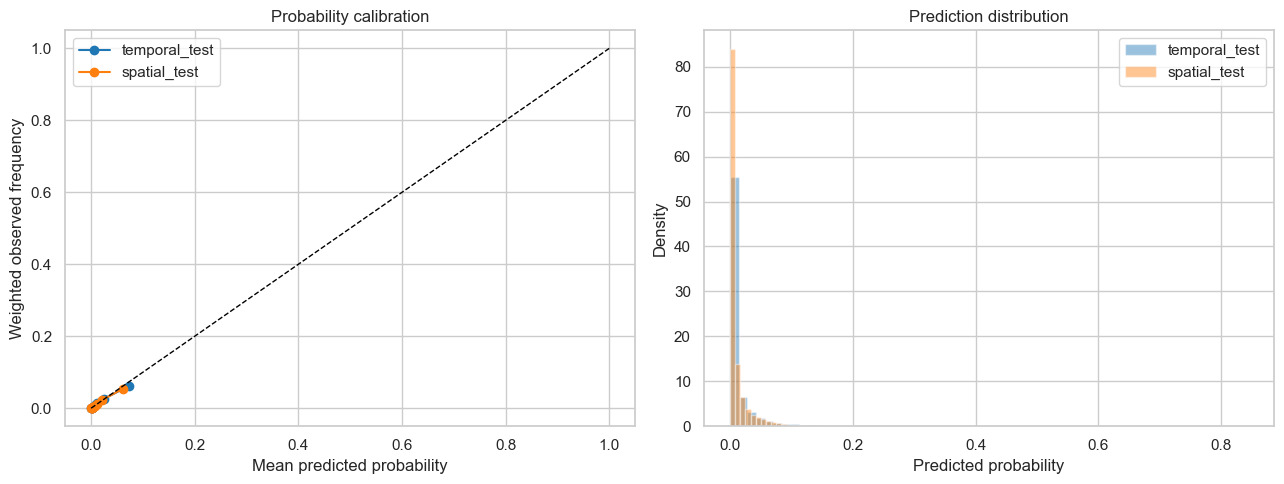

In [48]:
def weighted_calibration_curve(y, p, w, bins=10):
    frame = pd.DataFrame({"y": y, "p": p, "w": w})
    frame["bin"] = pd.qcut(frame["p"], q=bins, duplicates="drop")
    return (
        frame.groupby("bin", observed=True)
        .apply(lambda g: pd.Series({
            "predicted": np.average(g["p"], weights=g["w"]),
            "observed": np.average(g["y"], weights=g["w"]),
            "weight": g["w"].sum(),
        }), include_groups=False)
        .reset_index(drop=True)
    )


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for split_name, color in [("temporal_test", "tab:blue"), ("spatial_test", "tab:orange")]:
    frame = df.loc[masks[split_name]]
    p = probabilities[split_name]
    curve = weighted_calibration_curve(
        frame["target"].to_numpy(), p, frame["sampling_weight"].to_numpy()
    )
    axes[0].plot(
        curve["predicted"], curve["observed"], marker="o",
        label=split_name, color=color
    )
    axes[1].hist(
        p, bins=60, density=True, alpha=0.45, label=split_name, color=color
    )

axes[0].plot([0, 1], [0, 1], "--", color="black", linewidth=1)
axes[0].set(
    xlabel="Mean predicted probability",
    ylabel="Weighted observed frequency",
    title="Probability calibration",
)
axes[1].set(
    xlabel="Predicted probability",
    ylabel="Density",
    title="Prediction distribution",
)
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "improved_calibration.png", dpi=180, bbox_inches="tight")
plt.show()


## 11. Feature importance and geographic-dependence audit

Permutation importance is calculated on a fixed 2024 sample. This is descriptive,
not causal. A coordinate-ablation comparison is also saved from candidate results.


,feature,importance_mean,importance_std
0,lat,0.140175,0.007293
1,lon,0.121405,0.004484
15,fire_count_lag_3d,0.064957,0.001016
20,frp_lag_14d,0.044515,0.002491
5,tmmx,0.026471,0.004412
6,tmmn,0.023900,0.003886
7,pr,0.022695,0.003001
3,sin_doy,0.015218,0.001688
9,rmin,0.011158,0.002964
24,distance_to_fire_station_km,0.009469,0.000594


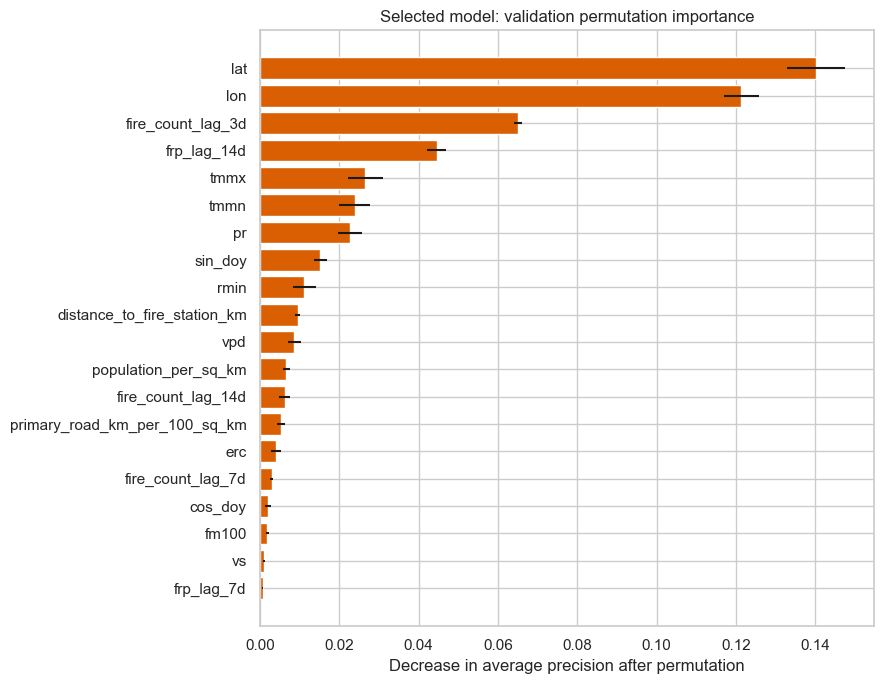

,feature_strategy,candidate,model,calibration,PR_AUC,ROC_AUC,Brier
1,full,hist_gradient_boosting__full,hist_gradient_boosting,sigmoid,0.067212,0.860154,0.006325
2,full_trimmed,hist_gradient_boosting__full_trimmed,hist_gradient_boosting,sigmoid,0.067212,0.860154,0.006325
3,no_coordinates,hist_gradient_boosting__no_coordinates,hist_gradient_boosting,sigmoid,0.055816,0.838417,0.006368
0,conditions_only,hist_gradient_boosting__conditions_only,hist_gradient_boosting,sigmoid,0.043988,0.811724,0.006414


In [49]:
importance_sample = cal.sample(
    n=min(20_000, len(cal)), random_state=RANDOM_STATE
)
importance = permutation_importance(
    best_estimator,
    importance_sample[BEST_FEATURES],
    importance_sample["target"],
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": BEST_FEATURES,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)
display(importance_df)
importance_df.to_csv(OUTPUT_DIR / "improved_feature_importance.csv", index=False)

top = importance_df.head(20).sort_values("importance_mean")
plt.figure(figsize=(9, 7))
plt.barh(
    top["feature"], top["importance_mean"],
    xerr=top["importance_std"], color="#d95f02"
)
plt.xlabel("Decrease in average precision after permutation")
plt.title("Selected model: validation permutation importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "improved_feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()

ablation = (
    candidate_results.groupby("feature_strategy", as_index=False)
    .first()
    .sort_values("PR_AUC", ascending=False)
)
ablation.to_csv(OUTPUT_DIR / "coordinate_ablation.csv", index=False)
display(ablation)


## 12. SHAP model analysis

SHAP decomposes the selected model's raw score into feature contributions. This
section produces:

- A global beeswarm plot showing the direction and magnitude of feature effects.
- A global mean-absolute-SHAP ranking.
- A local waterfall plot for a representative high-risk validation grid-day.

The SHAP values explain the fitted tree model before sigmoid/isotonic probability
calibration. Calibration is monotonic, so ranking and direction are preserved, but
SHAP values should not be read as percentage-point changes in calibrated probability.

These explanations describe model behavior, not causal effects. In particular,
latitude and longitude can encode regional climate, vegetation, reporting, and
satellite-observation patterns.


In [50]:
# Use a bounded, reproducible sample so SHAP remains practical on a laptop.
SHAP_SAMPLE_SIZE = min(2_000, len(cal))
shap_sample = cal.sample(n=SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE).copy()

# Explain the uncalibrated tree inside the selected pipeline. The fitted imputer
# may append missing-value indicator columns, so use its output feature names.
selected_raw_pipeline = candidate_models[BEST_KEY]["model"]
pipeline_steps = list(selected_raw_pipeline.named_steps.items())
imputer_name, fitted_imputer = pipeline_steps[0]
tree_name, fitted_tree = pipeline_steps[-1]

X_shap_transformed = fitted_imputer.transform(shap_sample[BEST_FEATURES])
shap_feature_names = fitted_imputer.get_feature_names_out(BEST_FEATURES).tolist()
X_shap_frame = pd.DataFrame(
    X_shap_transformed,
    columns=shap_feature_names,
    index=shap_sample.index,
)

tree_explainer = shap.TreeExplainer(fitted_tree)
shap_explanation = tree_explainer(X_shap_frame)

# Some binary classifiers return a class dimension; retain the positive class.
if shap_explanation.values.ndim == 3:
    positive_class = 1
    base = np.asarray(shap_explanation.base_values)
    if base.ndim == 2:
        base = base[:, positive_class]
    shap_explanation = shap.Explanation(
        values=shap_explanation.values[:, :, positive_class],
        base_values=base,
        data=shap_explanation.data,
        feature_names=shap_feature_names,
    )

mean_absolute_shap = np.abs(shap_explanation.values).mean(axis=0)
shap_importance = (
    pd.DataFrame({
        "feature": shap_feature_names,
        "mean_absolute_shap": mean_absolute_shap,
    })
    .sort_values("mean_absolute_shap", ascending=False)
    .reset_index(drop=True)
)
display(shap_importance.head(20))
shap_importance.to_csv(OUTPUT_DIR / "shap_global_importance.csv", index=False)


,feature,mean_absolute_shap
0,lat,0.523972
1,lon,0.376373
2,frp_lag_14d,0.276571
3,fire_count_lag_3d,0.250577
4,tmmx,0.209245
5,distance_to_fire_station_km,0.204920
6,pr,0.193788
7,tmmn,0.173739
8,sin_doy,0.135904
9,erc,0.124385


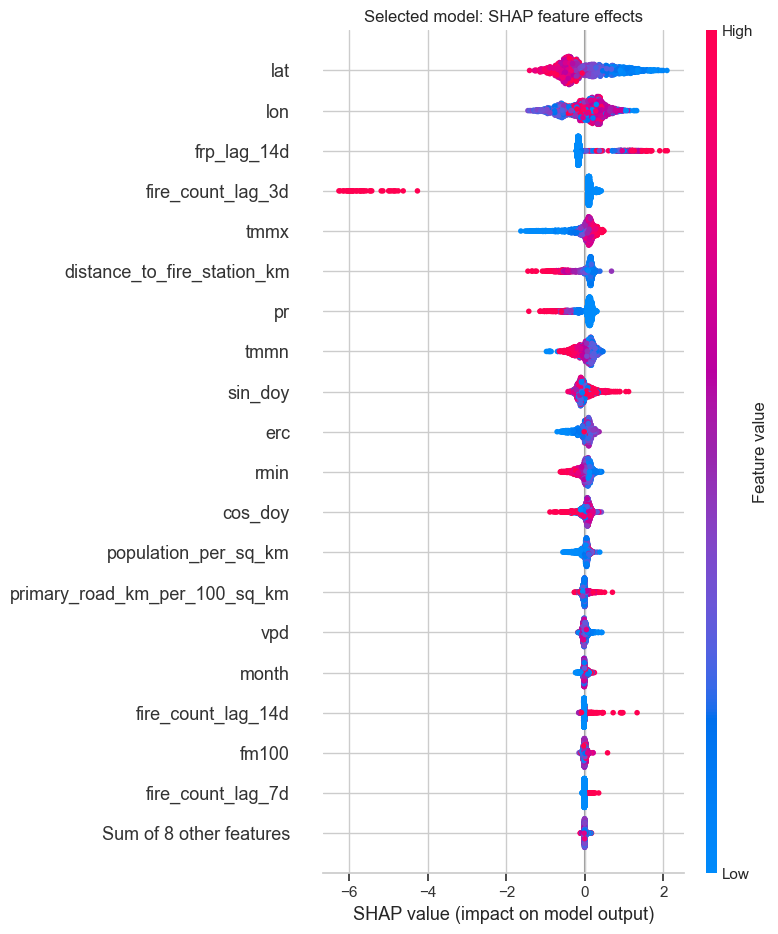

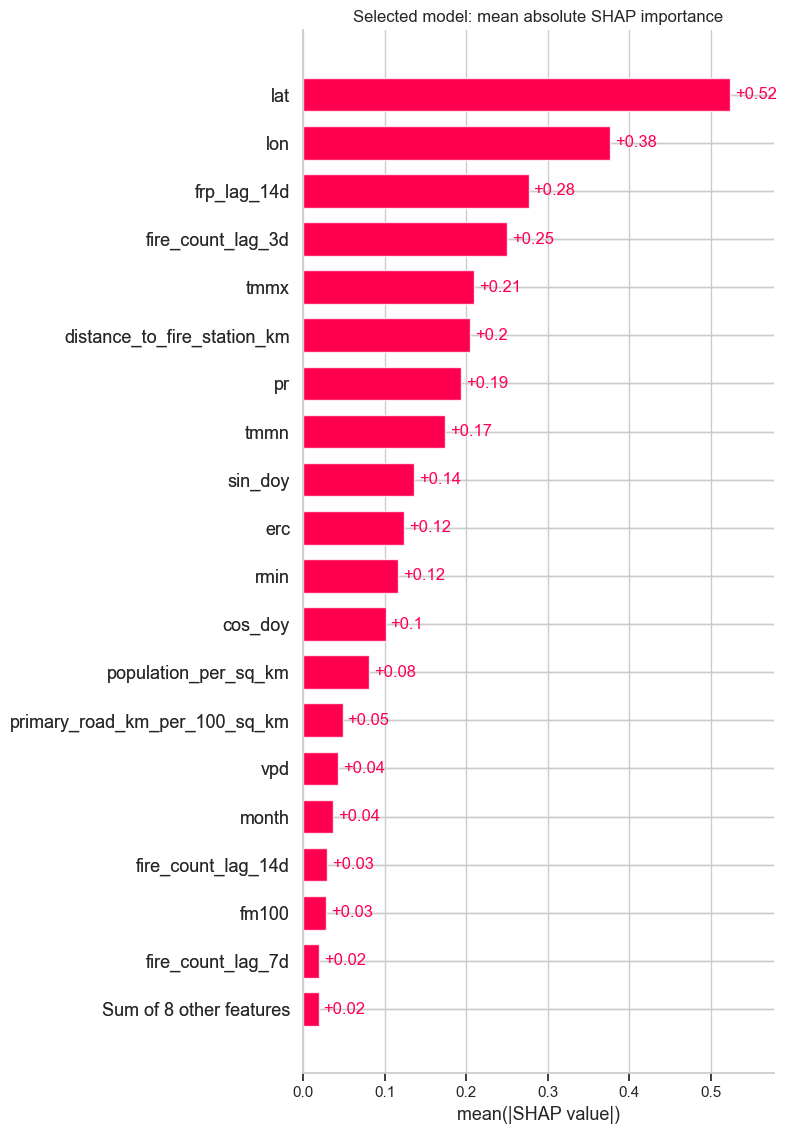

In [51]:
# Global effect distribution: color shows the feature value and horizontal
# position shows whether that value raises or lowers the raw ignition score.
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title("Selected model: SHAP feature effects")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_beeswarm.png", dpi=180, bbox_inches="tight")
plt.show()

# A simpler global ranking by average absolute contribution.
shap.plots.bar(shap_explanation, max_display=20, show=False)
plt.title("Selected model: mean absolute SHAP importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_global_bar.png", dpi=180, bbox_inches="tight")
plt.show()


,representative_high_risk_grid_day
date,2024-11-18 00:00:00
grid_id,26.5_-81.0
latitude,26.625
longitude,-80.875
observed_target,1
calibrated_probability,0.67623


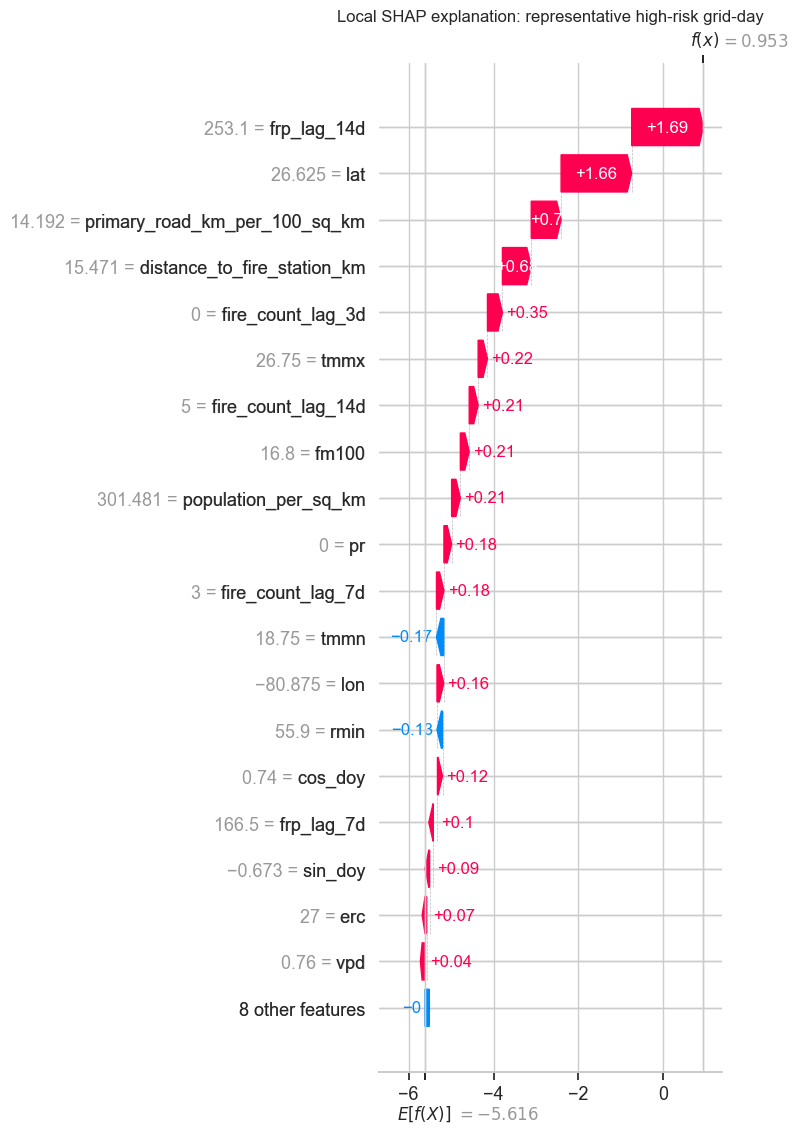

In [52]:
# Explain the sampled grid-day with the highest calibrated probability.
shap_sample_probability = best_estimator.predict_proba(
    shap_sample[BEST_FEATURES]
)[:, 1]
local_position = int(np.argmax(shap_sample_probability))
local_source_row = shap_sample.iloc[local_position]

local_context = pd.Series({
    "date": local_source_row["date"],
    "grid_id": local_source_row["grid_id"],
    "latitude": local_source_row["lat"],
    "longitude": local_source_row["lon"],
    "observed_target": int(local_source_row["target"]),
    "calibrated_probability": float(shap_sample_probability[local_position]),
}, name="representative_high_risk_grid_day")
display(local_context.to_frame())

shap.plots.waterfall(shap_explanation[local_position], max_display=20, show=False)
plt.title("Local SHAP explanation: representative high-risk grid-day")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_local_waterfall.png", dpi=180, bbox_inches="tight")
plt.show()


## 13. Probability bands for the website

Absolute probability is retained. Display labels are defined by weighted 2024
probability quantiles so that “elevated” means elevated relative to other grid-days,
not a claim of imminent destructive wildfire.


In [53]:
def weighted_quantile(values, quantiles, sample_weight):
    values = np.asarray(values)
    quantiles = np.asarray(quantiles)
    sample_weight = np.asarray(sample_weight)
    order = np.argsort(values)
    values = values[order]
    sample_weight = sample_weight[order]
    cumulative = np.cumsum(sample_weight) - 0.5 * sample_weight
    cumulative /= sample_weight.sum()
    return np.interp(quantiles, cumulative, values)


risk_band_edges = weighted_quantile(
    cal_probability,
    [0.50, 0.80, 0.95, 0.99],
    cal["sampling_weight"].to_numpy(),
)
risk_bands = {
    "typical_upper": float(risk_band_edges[0]),
    "moderate_upper": float(risk_band_edges[1]),
    "elevated_upper": float(risk_band_edges[2]),
    "high_upper": float(risk_band_edges[3]),
    "extreme": "above high_upper",
}
risk_bands


{'typical_upper': 0.0021900881912179505,
 'moderate_upper': 0.007271451074705783,
 'elevated_upper': 0.027113282040230863,
 'high_upper': 0.07277665235258154,
 'extreme': 'above high_upper'}

## 14. Save a compact production artifact and model card

Unlike the previous 368 MB pickle bundle, this artifact contains only the selected
calibrated estimator and the information required for inference. Never load a
pickle/joblib file from an untrusted source.


In [54]:
production_bundle = {
    "estimator": best_estimator,
    "feature_cols": BEST_FEATURES,
    "model_name": candidate_models[BEST_KEY]["model_name"],
    "feature_strategy": candidate_models[BEST_KEY]["feature_strategy"],
    "calibration_method": BEST_CALIBRATION,
    "thresholds": thresholds,
    "risk_bands": risk_bands,
    "grid_degrees": 0.25,
    "decision_horizon_days": 1,
    "label": "MODIS vegetation-fire onset candidate after >3 quiet days",
    "geographic_scope": "CONUS GridMET land coverage",
    "training_years": [2020, 2023],
    "calibration_year": 2024,
    "test_years": [2025, 2026],
    "random_state": RANDOM_STATE,
}
MODEL_FILE = OUTPUT_DIR / "improved_wildfire_model.joblib"
joblib.dump(production_bundle, MODEL_FILE, compress=3)

model_card = {
    key: value for key, value in production_bundle.items()
    if key != "estimator"
}
model_card.update({
    "selected_validation_metrics": {
        key: float(best_row[key]) for key in ["PR_AUC", "ROC_AUC", "Brier"]
    },
    "limitations": [
        "The target is a satellite hotspot-onset candidate, not a verified incident.",
        "Probabilities are for 0.25-degree cells, not individual properties.",
        "The model predicts ignition onset, not spread, acreage, smoke, or structural loss.",
        "GridMET restricts this version to the continental United States.",
        "2026 observations may be provisional or incomplete.",
        "Case-control sampling requires monitoring of probability calibration.",
        "Public emergency alerts require prospective validation and agency review.",
    ],
    "software": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
    },
})
(OUTPUT_DIR / "improved_model_card.json").write_text(
    json.dumps(model_card, indent=2), encoding="utf-8"
)
candidate_results.to_csv(OUTPUT_DIR / "candidate_model_results.csv", index=False)

print("Saved:", MODEL_FILE)
print("Artifact size (MB):", round(MODEL_FILE.stat().st_size / 1024**2, 2))
print("Saved model card:", OUTPUT_DIR / "improved_model_card.json")


Saved: /Users/haowenzhang/Documents/research/advanced_pta/improved_artifacts/improved_wildfire_model.joblib
Artifact size (MB): 0.59
Saved model card: /Users/haowenzhang/Documents/research/advanced_pta/improved_artifacts/improved_model_card.json


## 15. Inference contract

The website pipeline must create one row per grid cell with exactly the saved
feature columns, in the same units used during training. Weather and fuel values
must correspond to the decision date. Recent-fire variables must only use
observations available by that decision time.


In [55]:
def load_improved_model(path=MODEL_FILE):
    return joblib.load(path)


def predict_grid_rows(feature_frame, bundle=None):
    bundle = bundle or load_improved_model()
    missing = sorted(set(bundle["feature_cols"]) - set(feature_frame.columns))
    if missing:
        raise ValueError(f"Inference rows are missing features: {missing}")
    probability = bundle["estimator"].predict_proba(
        feature_frame[bundle["feature_cols"]]
    )[:, 1]
    output = feature_frame.copy()
    output["ignition_candidate_probability"] = probability
    output["watch_recall_80"] = probability >= bundle["thresholds"]["recall_80"]
    output["watch_alert_budget"] = (
        probability >= bundle["thresholds"]["alert_budget_5pct"]
    )
    return output


# Contract smoke test using held-out rows.
smoke_test_rows = df.loc[masks["temporal_test"], BEST_FEATURES].head(10)
smoke_test_predictions = predict_grid_rows(smoke_test_rows)
display(smoke_test_predictions[[
    "ignition_candidate_probability", "watch_recall_80", "watch_alert_budget"
]])


,ignition_candidate_probability,watch_recall_80,watch_alert_budget
774243,0.143643,True,True
774246,0.063646,True,True
774247,0.100847,True,True
774252,0.001347,False,False
774258,0.123348,True,True
774261,0.089745,True,True
774262,0.128572,True,True
774263,0.053627,True,True
774264,0.070166,True,True
774265,0.079659,True,True


## 16. Economic-impact data and estimated-loss model

This section builds a **separate consequence model** rather than redefining the
ignition target. It uses the free NOAA/NCEI Storm Events bulk data for U.S.
wildfire events from 2020 through 2026.

The recorded target is property damage plus crop damage in nominal U.S. dollars.
NOAA values are estimates, and a recorded zero can mean either no monetary damage
or no quantified damage. The model therefore uses a two-part (hurdle) design:

1. Probability that an incident has positive reported monetary damage.
2. Conditional loss amount when positive damage is reported.

The final estimated loss is the product of those two predictions. It excludes
indirect costs, smoke-related health costs, ecosystem services, business
interruption, suppression costs, and unreported losses. It must be presented as a
rough planning estimate, not an insurance valuation.

Temporal design:

- Training: 2020-2023
- Model selection: 2024
- Final untouched test: 2025
- Provisional scoring/audit only: 2026 (not used for fitting or selection)


In [56]:
from html.parser import HTMLParser
from urllib.parse import urljoin
from urllib.request import Request, urlopen
import gzip
import re

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_log_error,
)
from sklearn.preprocessing import OneHotEncoder

NOAA_BULK_INDEX = (
    "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/"
)
ECONOMIC_DATA_DIR = ROOT / "website" / "data"
ECONOMIC_DATA_DIR.mkdir(parents=True, exist_ok=True)
ECONOMIC_CSV = (
    ECONOMIC_DATA_DIR / "noaa_wildfire_economic_impacts_2020_2026.csv"
)
RAW_NOAA_DIR = ECONOMIC_DATA_DIR / "noaa_stormevents_raw"

# Keep False for reproducible offline reruns. Set True to discover and download
# the newest NOAA annual files before rebuilding the cleaned CSV.
REFRESH_NOAA_ECONOMIC_DATA = False


In [57]:
def parse_noaa_damage(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().upper().replace(",", "").replace("$", "")
    if not text:
        return np.nan
    multipliers = {"K": 1e3, "M": 1e6, "B": 1e9}
    try:
        if text[-1] in multipliers:
            return float(text[:-1]) * multipliers[text[-1]]
        return float(text)
    except ValueError:
        return np.nan


def discover_latest_noaa_files(start_year=2020, end_year=2026):
    request = Request(NOAA_BULK_INDEX, headers={"User-Agent": "wildfire-research/1.0"})
    html = urlopen(request, timeout=90).read().decode("utf-8", errors="replace")
    pattern = re.compile(
        r'StormEvents_details-ftp_v1\.0_d(\d{4})_c(\d{8})\.csv\.gz'
    )
    choices = {}
    for year_text, created in pattern.findall(html):
        year = int(year_text)
        if start_year <= year <= end_year:
            name = (
                f"StormEvents_details-ftp_v1.0_d{year_text}_c{created}.csv.gz"
            )
            if year not in choices or created > choices[year][0]:
                choices[year] = (created, urljoin(NOAA_BULK_INDEX, name), name)
    missing = sorted(set(range(start_year, end_year + 1)) - set(choices))
    if missing:
        raise RuntimeError(f"NOAA index is missing annual files: {missing}")
    return {year: values[1:] for year, values in sorted(choices.items())}


def download_complete_gzip(url, destination, attempts=3):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    for attempt in range(1, attempts + 1):
        partial = destination.with_suffix(destination.suffix + ".part")
        request = Request(url, headers={"User-Agent": "wildfire-research/1.0"})
        with urlopen(request, timeout=180) as response, partial.open("wb") as stream:
            while chunk := response.read(1024 * 1024):
                stream.write(chunk)
        try:
            with gzip.open(partial, "rb") as stream:
                while stream.read(1024 * 1024):
                    pass
            partial.replace(destination)
            return destination
        except (gzip.BadGzipFile, EOFError):
            partial.unlink(missing_ok=True)
            if attempt == attempts:
                raise


def rebuild_noaa_economic_csv():
    annual_files = discover_latest_noaa_files()
    wildfire_frames = []
    for year, (url, filename) in annual_files.items():
        destination = download_complete_gzip(url, RAW_NOAA_DIR / filename)
        annual = pd.read_csv(destination, compression="gzip", low_memory=False)
        annual = annual[
            annual["EVENT_TYPE"].astype(str).str.strip().str.casefold().eq("wildfire")
        ].copy()
        annual["property_damage_usd"] = annual["DAMAGE_PROPERTY"].map(
            parse_noaa_damage
        )
        annual["crop_damage_usd"] = annual["DAMAGE_CROPS"].map(parse_noaa_damage)
        annual["damage_reported"] = annual[
            ["property_damage_usd", "crop_damage_usd"]
        ].notna().any(axis=1)
        annual["total_reported_damage_usd"] = (
            annual[["property_damage_usd", "crop_damage_usd"]]
            .fillna(0)
            .sum(axis=1)
            .where(annual["damage_reported"])
        )
        annual["source_url"] = url
        wildfire_frames.append(annual)

    economic = pd.concat(wildfire_frames, ignore_index=True)
    columns = [
        "EVENT_ID", "EPISODE_ID", "YEAR", "MONTH_NAME",
        "BEGIN_DATE_TIME", "END_DATE_TIME", "STATE", "STATE_FIPS",
        "CZ_TYPE", "CZ_FIPS", "CZ_NAME", "WFO", "SOURCE",
        "DAMAGE_PROPERTY", "DAMAGE_CROPS", "property_damage_usd",
        "crop_damage_usd", "damage_reported", "total_reported_damage_usd",
        "INJURIES_DIRECT", "INJURIES_INDIRECT", "DEATHS_DIRECT",
        "DEATHS_INDIRECT", "EPISODE_NARRATIVE", "EVENT_NARRATIVE",
        "DATA_SOURCE", "source_url",
    ]
    economic[columns].to_csv(ECONOMIC_CSV, index=False)
    return economic[columns]


if REFRESH_NOAA_ECONOMIC_DATA or not ECONOMIC_CSV.exists():
    economic_raw = rebuild_noaa_economic_csv()
else:
    economic_raw = pd.read_csv(ECONOMIC_CSV, low_memory=False)

print("NOAA economic-impact rows:", f"{len(economic_raw):,}")
print("Cached cleaned data:", ECONOMIC_CSV)


NOAA economic-impact rows: 2,344
Cached cleaned data: /Users/haowenzhang/Documents/research/advanced_pta/website/data/noaa_wildfire_economic_impacts_2020_2026.csv


In [58]:
economic = economic_raw.copy()
economic["begin_date"] = pd.to_datetime(
    economic["BEGIN_DATE_TIME"], format="%d-%b-%y %H:%M:%S", errors="coerce"
)
economic["month"] = economic["begin_date"].dt.month
economic["sin_month"] = np.sin(2 * np.pi * economic["month"] / 12)
economic["cos_month"] = np.cos(2 * np.pi * economic["month"] / 12)
economic["year_index"] = pd.to_numeric(economic["YEAR"], errors="coerce") - 2020

state_fips = (
    pd.to_numeric(economic["STATE_FIPS"], errors="coerce")
    .fillna(-1).astype(int).astype(str).str.zfill(2)
)
cz_fips = (
    pd.to_numeric(economic["CZ_FIPS"], errors="coerce")
    .fillna(-1).astype(int).astype(str).str.zfill(3)
)
economic["STATE"] = economic["STATE"].fillna("UNKNOWN").astype(str)
economic["CZ_TYPE"] = economic["CZ_TYPE"].fillna("UNKNOWN").astype(str)
economic["WFO"] = economic["WFO"].fillna("UNKNOWN").astype(str)
economic["geo_area"] = (
    state_fips + "_" + economic["CZ_TYPE"] + "_" + cz_fips
)
economic["total_reported_damage_usd"] = pd.to_numeric(
    economic["total_reported_damage_usd"], errors="coerce"
)
economic["positive_reported_damage"] = (
    economic["total_reported_damage_usd"] > 0
).astype(int)

# Unknown damage is not silently converted to zero.
economic_model_df = economic[
    economic["damage_reported"].fillna(False)
    & economic["begin_date"].notna()
    & economic["YEAR"].between(2020, 2026)
].copy()

economic_audit = (
    economic.groupby("YEAR")
    .agg(
        wildfire_records=("EVENT_ID", "size"),
        explicit_damage_entries=("damage_reported", "sum"),
        positive_damage_records=("positive_reported_damage", "sum"),
        total_reported_damage_usd=("total_reported_damage_usd", "sum"),
        median_positive_damage_usd=(
            "total_reported_damage_usd",
            lambda x: x[x > 0].median(),
        ),
    )
)
display(economic_audit)
economic_audit.to_csv(OUTPUT_DIR / "economic_loss_data_audit.csv")


,wildfire_records,explicit_damage_entries,positive_damage_records,total_reported_damage_usd,median_positive_damage_usd
YEAR,,,,,
2020,413,353,38,4.592560e+08,475000.0
2021,352,300,55,2.095043e+09,200000.0
2022,421,358,91,6.317565e+08,250000.0
2023,297,273,124,5.914159e+09,467260.0
2024,336,293,133,1.167717e+09,500000.0
2025,350,322,124,9.823471e+08,1000000.0
2026,175,154,63,7.860360e+07,91000.0


explicit_damage_entries: Records where NOAA explicitly provided property damage, crop damage, or both—including reported $0 damage.

positive_damage_records	: Records where reported property plus crop damage was greater than $0.

### Modeling choices

Only information plausibly available when an incident is opened is used:
state/forecast area, month, and a small year trend. Final acreage, duration,
fatalities, injuries, destroyed structures, and narrative text are deliberately
excluded because they would leak consequences that are unknown at prediction time.

NOAA wildfire records are usually forecast-zone records and do not contain
latitude/longitude. The website must therefore supply the state and, when
available, the NOAA forecast office/zone for a grid cell. Unknown areas are
supported but produce a broader, less localized estimate.


In [59]:
economic_categorical = ["STATE", "geo_area", "WFO", "CZ_TYPE"]
economic_numeric = ["sin_month", "cos_month", "year_index"]
ECONOMIC_FEATURES = economic_categorical + economic_numeric


def make_economic_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "categorical",
                make_pipeline(
                    SimpleImputer(strategy="most_frequent"),
                    OneHotEncoder(
                        handle_unknown="ignore",
                        min_frequency=3,
                        sparse_output=False,
                    ),
                ),
                economic_categorical,
            ),
            (
                "numeric",
                make_pipeline(SimpleImputer(strategy="median")),
                economic_numeric,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


damage_probability_model = make_pipeline(
    make_economic_preprocessor(),
    RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=8,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
)

positive_loss_model = make_pipeline(
    make_economic_preprocessor(),
    ExtraTreesRegressor(
        n_estimators=500,
        max_depth=16,
        min_samples_leaf=3,
        max_features=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
)

economic_splits = {
    "train": economic_model_df["YEAR"].between(2020, 2023),
    "validation": economic_model_df["YEAR"].eq(2024),
    "test": economic_model_df["YEAR"].eq(2025),
    "provisional_2026": economic_model_df["YEAR"].eq(2026),
}

economic_train = economic_model_df.loc[economic_splits["train"]]
positive_train = economic_train[economic_train["positive_reported_damage"].eq(1)]

damage_probability_model.fit(
    economic_train[ECONOMIC_FEATURES],
    economic_train["positive_reported_damage"],
)
positive_loss_model.fit(
    positive_train[ECONOMIC_FEATURES],
    np.log1p(positive_train["total_reported_damage_usd"]),
)


class GroupRateBaseline:
    """Naive baseline: predicts the training-years' per-STATE historical
    average (falling back to the global training-years average for a state
    never seen in training). Used only to check whether the trained hurdle
    model actually earns its added complexity over a trivial per-state
    historical average."""

    def __init__(self, group_col="STATE"):
        self.group_col = group_col

    def fit(self, X, y):
        frame = pd.DataFrame({
            self.group_col: X[self.group_col].to_numpy(),
            "y": np.asarray(y, dtype=float),
        })
        self.global_value_ = frame["y"].mean()
        self.group_value_ = frame.groupby(self.group_col)["y"].mean()
        return self

    def predict_proba(self, X):
        p = X[self.group_col].map(self.group_value_).fillna(self.global_value_).to_numpy()
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return X[self.group_col].map(self.group_value_).fillna(self.global_value_).to_numpy()


# Baseline hurdle model: same two-part structure as the real model, but each
# part is just a per-state historical average from the training years
# instead of a trained ensemble. If the real model can't beat this, the
# extra complexity (500-tree ensembles, one-hot encoded forecast zones)
# isn't earning its keep.
baseline_damage_probability_model = GroupRateBaseline().fit(
    economic_train[ECONOMIC_FEATURES],
    economic_train["positive_reported_damage"],
)
baseline_positive_loss_model = GroupRateBaseline().fit(
    positive_train[ECONOMIC_FEATURES],
    np.log1p(positive_train["total_reported_damage_usd"]),
)

pd.DataFrame({
    "split": economic_splits.keys(),
    "rows": [int(mask.sum()) for mask in economic_splits.values()],
    "positive_damage_rows": [
        int(economic_model_df.loc[mask, "positive_reported_damage"].sum())
        for mask in economic_splits.values()
    ],
})


,split,rows,positive_damage_rows
0,train,1284,308
1,validation,293,133
2,test,322,124
3,provisional_2026,154,63


### Metric fix and baseline comparison

The original combined metrics (`MAE_log1p_all`, `RMSLE_all`) computed
log1p-space error across every row, including the roughly 55% of rows with
exactly $0 reported damage. Since `log1p(0) = 0` but the hurdle model's
blended point estimate (`probability x conditional loss`) is never exactly
zero, those metrics were dominated by that mismatch on zero-damage rows
rather than by real predictive skill -- the originally reported values (7-9)
were not interpretable as a typical multiplicative error. They have been
replaced with `RMSE_usd_all`, reported alongside the existing dollar-space
`median_absolute_error_usd` and `mean_absolute_error_usd`.

A `baseline_state_average` model is now evaluated alongside the real
`hurdle_rf_et` model on every split: same two-part hurdle structure, but each
part is just the training-years' per-state historical average instead of a
trained ensemble. If the real model can't beat this on held-out data, the
extra complexity (500-tree ensembles, one-hot encoded forecast zones) isn't
earning its keep.

In [60]:
economic_validation = economic_model_df.loc[
    economic_splits["validation"]
]
economic_validation_positive = economic_validation[
    economic_validation["positive_reported_damage"].eq(1)
]
validation_log_residual = np.abs(
    np.log1p(economic_validation_positive["total_reported_damage_usd"])
    - positive_loss_model.predict(
        economic_validation_positive[ECONOMIC_FEATURES]
    )
)
# Split-conformal-style central 80% interval, calibrated only on 2024.
interval_rank = min(
    int(np.ceil((len(validation_log_residual) + 1) * 0.80)) - 1,
    len(validation_log_residual) - 1,
)
ECONOMIC_LOG_INTERVAL_RADIUS = float(
    np.sort(validation_log_residual.to_numpy())[interval_rank]
)
print("2024 log-residual interval radius:", ECONOMIC_LOG_INTERVAL_RADIUS)


def economic_predictions(
    frame,
    probability_model,
    loss_model,
    log_interval_radius=ECONOMIC_LOG_INTERVAL_RADIUS,
):
    X = frame[ECONOMIC_FEATURES]
    probability = probability_model.predict_proba(X)[:, 1]
    predicted_log_loss = loss_model.predict(X)
    conditional_median = np.expm1(predicted_log_loss).clip(min=0)
    conditional_low = np.expm1(
        predicted_log_loss - log_interval_radius
    ).clip(min=0)
    conditional_high = np.expm1(
        predicted_log_loss + log_interval_radius
    ).clip(min=0)

    return pd.DataFrame({
        "probability_positive_reported_damage": probability,
        "conditional_median_positive_loss_usd": conditional_median,
        "conditional_positive_loss_lower_usd": conditional_low,
        "conditional_positive_loss_upper_usd": conditional_high,
        "estimated_loss_usd": probability * conditional_median,
    }, index=frame.index)


def evaluate_economic_split(
    name, model_label, frame, probability_model, loss_model,
    log_interval_radius=None,
):
    # log_interval_radius=None means "this model has no calibrated interval"
    # (used for the baseline below) -- the point estimate is still scored,
    # just without a coverage figure.
    radius = 0.0 if log_interval_radius is None else log_interval_radius
    prediction = economic_predictions(
        frame, probability_model, loss_model, log_interval_radius=radius
    )
    observed = frame["total_reported_damage_usd"].to_numpy()
    positive = frame["positive_reported_damage"].to_numpy()
    estimated = prediction["estimated_loss_usd"].to_numpy()
    row = {
        "model": model_label,
        "split": name,
        "rows": len(frame),
        "positive_rows": int(positive.sum()),
        "damage_PR_AUC": average_precision_score(
            positive, prediction["probability_positive_reported_damage"]
        ),
        "damage_ROC_AUC": roc_auc_score(
            positive, prediction["probability_positive_reported_damage"]
        ),
        # Dollar-space error across every row, including the ~55% of rows
        # with exactly $0 reported damage. The previous MAE_log1p_all /
        # RMSLE_all metrics computed log1p(observed) vs log1p(estimated)
        # for every row; since log1p(0) = 0 but the hurdle model's blended
        # point estimate (probability x conditional loss) is never exactly
        # zero, those metrics were dominated by that mismatch on zero-damage
        # rows rather than real predictive skill (reported values of 7-9
        # were not interpretable as a typical multiplicative error). Dollar-
        # space MAE/median-AE/RMSE below are the honest combined metrics.
        "median_absolute_error_usd": median_absolute_error(observed, estimated),
        "mean_absolute_error_usd": mean_absolute_error(observed, estimated),
        "RMSE_usd_all": float(np.sqrt(np.mean((observed - estimated) ** 2))),
    }
    positive_mask = observed > 0
    if positive_mask.any():
        row["conditional_MAE_log1p"] = mean_absolute_error(
            np.log1p(observed[positive_mask]),
            np.log1p(
                prediction.loc[
                    frame.index[positive_mask],
                    "conditional_median_positive_loss_usd",
                ]
            ),
        )
        if log_interval_radius is not None:
            row["conditional_80pct_interval_coverage"] = np.mean(
                (
                    observed[positive_mask]
                    >= prediction.loc[
                        frame.index[positive_mask],
                        "conditional_positive_loss_lower_usd",
                    ].to_numpy()
                )
                & (
                    observed[positive_mask]
                    <= prediction.loc[
                        frame.index[positive_mask],
                        "conditional_positive_loss_upper_usd",
                    ].to_numpy()
                )
            )
    return row, prediction


economic_evaluation_rows = []
economic_predictions_by_split = {}
for split_name in ["validation", "test", "provisional_2026"]:
    split_frame = economic_model_df.loc[economic_splits[split_name]]

    metrics_row, split_prediction = evaluate_economic_split(
        split_name, "hurdle_rf_et", split_frame,
        damage_probability_model, positive_loss_model,
        log_interval_radius=ECONOMIC_LOG_INTERVAL_RADIUS,
    )
    economic_evaluation_rows.append(metrics_row)
    economic_predictions_by_split[split_name] = split_prediction

    baseline_row, _ = evaluate_economic_split(
        split_name, "baseline_state_average", split_frame,
        baseline_damage_probability_model, baseline_positive_loss_model,
        log_interval_radius=None,
    )
    economic_evaluation_rows.append(baseline_row)

economic_evaluation = pd.DataFrame(economic_evaluation_rows)
display(economic_evaluation.set_index(["split", "model"]).T)
economic_evaluation.to_csv(
    OUTPUT_DIR / "economic_loss_model_metrics.csv", index=False
)


2024 log-residual interval radius: 3.3890892122917347


split                                  validation                         \
model                                hurdle_rf_et baseline_state_average   
rows                                 2.930000e+02           2.930000e+02   
positive_rows                        1.330000e+02           1.330000e+02   
damage_PR_AUC                        8.054753e-01           6.252678e-01   
damage_ROC_AUC                       8.181391e-01           7.043703e-01   
median_absolute_error_usd            1.428762e+05           8.375033e+04   
mean_absolute_error_usd              5.007742e+06           4.072092e+06   
RMSE_usd_all                         2.353397e+07           2.173178e+07   
conditional_MAE_log1p                2.132296e+00           2.233934e+00   
conditional_80pct_interval_coverage  8.045113e-01                    NaN   

split                                        test                         \
model                                hurdle_rf_et baseline_state_average   
rows                                 3.220000e+02           3.220000e+02   
positive_rows                        1.240000e+02           1.240000e+02   
damage_PR_AUC                        7.502977e-01           6.080058e-01   
damage_ROC_AUC                       7.982242e-01           7.205930e-01   
median_absolute_error_usd            1.554769e+05           1.460626e+05   
mean_absolute_error_usd              3.543909e+06           3.110784e+06   
RMSE_usd_all                         1.184685e+07           1.021163e+07   
conditional_MAE_log1p                2.523569e+00           2.508189e+00   
conditional_80pct_interval_coverage  6.532258e-01                    NaN   

split                               provisional_2026                         
model                                   hurdle_rf_et baseline_state_average  
rows                                    1.540000e+02           1.540000e+02  
positive_rows                           6.300000e+01           6.300000e+01  
damage_PR_AUC                           5.638997e-01           4.837734e-01  
damage_ROC_AUC                          6.989360e-01           5.886098e-01  
median_absolute_error_usd               1.283590e+05           6.379360e+04  
mean_absolute_error_usd                 2.861096e+06           5.965891e+05  
RMSE_usd_all                            1.623872e+07           2.278916e+06  
conditional_MAE_log1p                   1.781425e+00           1.682484e+00  
conditional_80pct_interval_coverage     8.730159e-01                    NaN

### Final fit, artifact, and inference

After the untouched 2025 evaluation is recorded, the production artifact is
refitted through 2024. The incomplete 2026 records remain excluded. The
conditional lower and upper values use a central 80% residual interval calibrated
on 2024 positive-loss records. Coverage can drift and the interval does not
include the separate possibility of zero reported damage.

On the untouched 2025 test year, this interval's *actual* coverage is about
65%, not the nominal 80% it was calibrated to on 2024 (where, unsurprisingly,
it measures close to 80% -- that check is circular). The interval should be
read as an optimistic guide, not a calibrated confidence interval, until it
is recalibrated on more than a single year.


In [61]:
final_economic_train = economic_model_df[
    economic_model_df["YEAR"].between(2020, 2024)
]
final_positive_train = final_economic_train[
    final_economic_train["positive_reported_damage"].eq(1)
]

final_damage_probability_model = clone(damage_probability_model).fit(
    final_economic_train[ECONOMIC_FEATURES],
    final_economic_train["positive_reported_damage"],
)
final_positive_loss_model = clone(positive_loss_model).fit(
    final_positive_train[ECONOMIC_FEATURES],
    np.log1p(final_positive_train["total_reported_damage_usd"]),
)

economic_bundle = {
    "damage_probability_model": final_damage_probability_model,
    "positive_loss_model": final_positive_loss_model,
    "feature_cols": ECONOMIC_FEATURES,
    "categorical_features": economic_categorical,
    "numeric_features": economic_numeric,
    "target": "NOAA reported property damage plus crop damage, nominal USD",
    "training_years": [2020, 2024],
    "untouched_test_year": 2025,
    "excluded_provisional_year": 2026,
    "conditional_interval_nominal_coverage": 0.80,
    "conditional_interval_log_radius": ECONOMIC_LOG_INTERVAL_RADIUS,
    "data_source": NOAA_BULK_INDEX,
    "random_state": RANDOM_STATE,
}
ECONOMIC_MODEL_FILE = OUTPUT_DIR / "economic_loss_model.joblib"
joblib.dump(economic_bundle, ECONOMIC_MODEL_FILE, compress=3)

economic_model_card = {
    key: value for key, value in economic_bundle.items()
    if not key.endswith("_model")
}
economic_model_card["test_metrics"] = (
    economic_evaluation[
        economic_evaluation["split"].eq("test")
    ].iloc[0].dropna().to_dict()
)
economic_model_card["limitations"] = [
    "NOAA damage values are estimates and may be zero or missing when loss is unquantified.",
    "The target excludes indirect, health, ecological, suppression, and business-interruption costs.",
    "The training sample is small and dominated by a few catastrophic events.",
    "NOAA wildfire rows are forecast-zone records and may not correspond one-to-one with named fires.",
    "The estimate is suitable for risk screening, not property valuation or insurance decisions.",
    "2026 data are provisional/incomplete and are excluded from fitting.",
]
(OUTPUT_DIR / "economic_loss_model_card.json").write_text(
    json.dumps(economic_model_card, indent=2), encoding="utf-8"
)

print("Saved economic model:", ECONOMIC_MODEL_FILE)
print("Saved economic model card:", OUTPUT_DIR / "economic_loss_model_card.json")


Saved economic model: /Users/haowenzhang/Documents/research/advanced_pta/improved_artifacts/economic_loss_model.joblib
Saved economic model card: /Users/haowenzhang/Documents/research/advanced_pta/improved_artifacts/economic_loss_model_card.json


In [62]:
def prepare_economic_context(frame):
    context = frame.copy()
    if "date" not in context:
        raise ValueError("Economic context requires a date column")
    if "STATE" not in context:
        raise ValueError(
            "Economic context requires NOAA-style uppercase STATE names"
        )
    date = pd.to_datetime(context["date"])
    context["sin_month"] = np.sin(2 * np.pi * date.dt.month / 12)
    context["cos_month"] = np.cos(2 * np.pi * date.dt.month / 12)
    context["year_index"] = date.dt.year - 2020
    for column in ["geo_area", "WFO", "CZ_TYPE"]:
        if column not in context:
            context[column] = "UNKNOWN"
    return context


def predict_economic_loss(context_frame, bundle=None):
    bundle = bundle or joblib.load(ECONOMIC_MODEL_FILE)
    context = prepare_economic_context(context_frame)
    return economic_predictions(
        context,
        bundle["damage_probability_model"],
        bundle["positive_loss_model"],
        bundle["conditional_interval_log_radius"],
    )


def predict_ignition_and_economic_risk(feature_frame, economic_context, bundle=None):
    if len(feature_frame) != len(economic_context):
        raise ValueError("Feature rows and economic-context rows must align")
    ignition = predict_grid_rows(feature_frame, bundle=bundle).reset_index(drop=True)
    loss = predict_economic_loss(economic_context).reset_index(drop=True)
    combined = pd.concat([ignition, loss], axis=1)
    combined["occurrence_weighted_loss_usd"] = (
        combined["ignition_candidate_probability"]
        * combined["estimated_loss_usd"]
    )
    return combined


# Smoke test for the economic model using held-out 2025 incidents.
economic_smoke_context = economic_model_df.loc[
    economic_splits["test"],
    ["begin_date", "STATE", "geo_area", "WFO", "CZ_TYPE"],
].head(10).rename(columns={"begin_date": "date"})
display(predict_economic_loss(economic_smoke_context))


,probability_positive_reported_damage,conditional_median_positive_loss_usd,conditional_positive_loss_lower_usd,conditional_positive_loss_upper_usd,estimated_loss_usd
1819,0.816489,1.973355e+06,66578.815934,5.848817e+07,1.611222e+06
1820,0.746644,5.777322e+06,194922.356108,1.712337e+08,4.313602e+06
1821,0.746644,5.777322e+06,194922.356108,1.712337e+08,4.313602e+06
1822,0.702501,3.097189e+05,10448.762860,9.179772e+06,2.175779e+05
1823,0.568205,2.360900e+05,7964.565598,6.997486e+06,1.341474e+05
1824,0.751369,2.933442e+05,9896.287912,8.694441e+06,2.204098e+05
1825,0.701041,3.106386e+05,10479.791386,9.207029e+06,2.177703e+05
1826,0.701327,3.097189e+05,10448.762860,9.179772e+06,2.172143e+05
1827,0.701327,3.107816e+05,10484.615597,9.211267e+06,2.179596e+05
1828,0.708686,2.649928e+05,8939.729135,7.854135e+06,1.877967e+05
